## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds, get_GHG
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Set path to folders containing all default and scenario data. Select the 'baseline' scenario, define years to calculate output for and create a container to store outputs per year. To save time we use 10-year time steps, but 1-year time steps are also possible.

In [3]:
# Set paths to default and scenario data
cm.ParameterRetriever.set_data_folders(
    default = os.path.join('..','data','prod_parameters'),
    scenarios = os.path.join('..','data','scenarios'),
    relation_tables = os.path.join('..','data','relation_tables.xlsx')
)

# Define scenario, years and create output container
scn = 'none'
year = '2020'
output = pd.DataFrame(
    columns=['dem','crp','ani'],
    index=pd.MultiIndex.from_frame(pd.DataFrame({'scn':[scn],'year':[year]}))
)

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [5]:
# Get region attributes
regions.calculate(verbose=True)

# Calculate food demand
demand.calculate(verbose=True)

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Adjust animal demand to stat (CHECK DEMAND DATA TO ALIGN!!!)
demand.animal_prod_demand.update(
    pd.Series(
        {
            ('conventional','cattle','meat') : (136-21) * 1000000,
            ('organic','cattle','meat')      : 21 * 1000000,
            ('conventional','cattle','milk') : (2760-464) * 1000000,
            ('organic','cattle','milk')      : 464 * 1000000,
            ('conventional','pigs','meat')   : (249-6) * 1000000,
            ('organic','pigs','meat')        : 6 * 1000000,
            ('conventional','poultry','eggs')   : (117.49-23.38) * 1000000,
            ('organic','poultry','eggs')        : 23.38 * 1000000,
            ('conventional','poultry','meat')   : (152-1.432) * 1000000,
            ('organic','poultry','meat')        : 1.432 * 1000000,
        },
    )
    .rename('food')
    .rename_axis(['prod_system','species','animal_prod'])
)

# Distribute animals and crops
# Make optimisation problem
geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.6, verbose=True)
# Solve optimisation problem
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':200000,
        'eps_abs':5e-6,
        'eps_rel':5e-6,
        'verbose':False
    }
)

# Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
feed_mgmt.calculate2(verbose=True)

# Calculate manure
manure_mgmt.calculate(verbose=True)

# Calculate plant nutrient management
plant_nutrient_mgmt.calculate(verbose=True)

# Calculate energy requirements
machinery_and_energy_mgmt.calculate(verbose=True)

# Store results
# Demand
output.loc[(scn,year),'dem'] = \
demand.make_static()
# Crops
output.loc[(scn,year),'crp'] = \
crops.make_static()
# Animals
output.loc[(scn,year),'ani'] = \
concat_herds(
    herds.apply(lambda x: x.make_static())
)

[07:37:51][Regions] Getting initial crop areas and animal numbers (x0) ...
[07:37:51][Regions] Getting climate and soil attributes ...
[07:37:51][Regions] Done! Elapsed time: 0 sec
[07:37:51][DemandAndConversions] Calculating food demand ...
[07:37:51][DemandAndConversions] Calculating waste ...
[07:37:51][DemandAndConversions] Calculating crop product demand ...
[07:37:52][DemandAndConversions] Calculating animal product demand ...
[07:37:53][DemandAndConversions] Done! Elapsed time: 2 sec
[07:37:53][CropProduction] Calculating harvest ...
[07:37:53][CropProduction] Calculating production ...
[07:37:58][CropProduction] Calculating crop residues ...
[07:37:59][CropProduction] Calculating seed demand ...
[07:38:01][CropProduction] Done! Elapsed time: 8 sec
[07:38:01][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[07:38:02][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[07:38:02][AnimalHerd (cattle, beef, conventional, none)] Do

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:163: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:163: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:163: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\g

[07:40:42][GeoDistributor.solve] Done! Elapsed time: 60 sec
[07:40:42][FeedMgmt] Adjusting feed rations (not implemented) ...
[07:40:42][FeedMgmt] Calculating enteric methane emissions ...
[07:40:44][FeedMgmt] Done! Elapsed time: 2 sec
[07:40:44][ManureMgmt] Calculating VS excretion ...
[07:40:47][ManureMgmt] Calculating VS losses ...
[07:40:49][ManureMgmt] Calculating N excretion ...
[07:40:52][ManureMgmt] Calculating N losses ...
[07:41:08][ManureMgmt] Calculating N available to spread ...
[07:41:10][ManureMgmt] Done! Elapsed time: 25 sec
[07:41:10][PlantNutrientMgmt] Calculating crop N requirements ...
[07:41:12][PlantNutrientMgmt] Distributing manure ...
[07:41:14][PlantNutrientMgmt] Calculating mineral N application ...
[07:41:15][PlantNutrientMgmt] Calculating N in crop residues ...
[07:41:15][PlantNutrientMgmt] Calculating N application losses ...
[07:41:15][PlantNutrientMgmt] Calculating N soil losses ...
[07:41:15][PlantNutrientMgmt] Done! Elapsed time: 6 sec
[07:41:15][Machin

## WIP fix animal demand

In [ ]:
demand.par = cm.ParameterRetriever('DemandAndConversions')
demand.calculate()

In [ ]:
stat = pd.Series(
    {
        ('conventional','cattle','meat') : (136-21),
        ('organic','cattle','meat')      : 21,
        ('conventional','cattle','milk') : (2760-464),
        ('organic','cattle','milk')      : 464,
        ('conventional','pigs','meat')   : (249-6),
        ('organic','pigs','meat')        : 6,
        ('conventional','poultry','meat')   : (152-0),
        ('organic','poultry','meat')        : 0,
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

In [ ]:
(demand.animal_prod_demand['food']/1000000 - stat)/(demand.animal_prod_demand['food']/1000000)*100

In [ ]:
stat

In [ ]:
demand.animal_prod_demand['food']/1000000

# Check solution

### GHG emissions compared to NIR

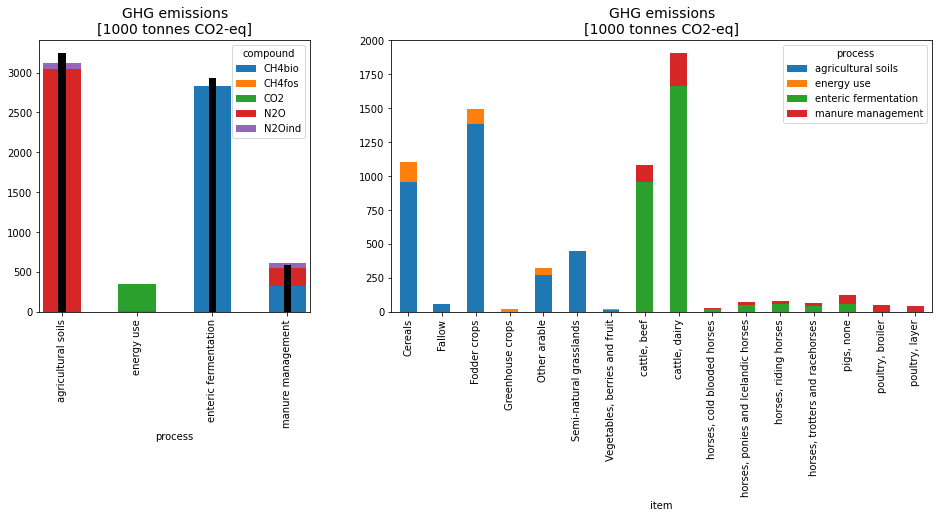

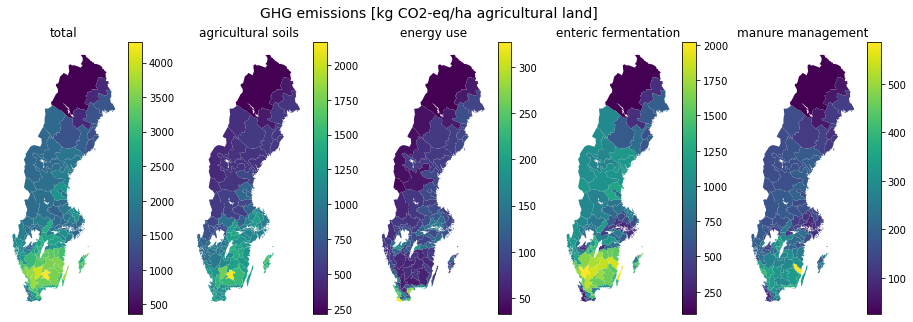

In [25]:
# Bar plot [1000 tonnes CO2eq] ----->
fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})
plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
plot_data_NIR = pd.Series(
    [3250,0,2930,590],
    index=pd.Index(['agricultural soils','energy use','enteric fermentation','manure management'], name='process')
)
ax=axs[0]
plot_data.plot.bar(stacked='True', ax=ax)
plot_data_NIR.plot.bar(stacked='True', ax=ax, width=0.1, color='black')

plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax.set_title('GHG emissions\n[1000 tonnes CO2-eq]', size=14)
ax = axs[1]
plot_data.plot.bar(stacked='True', ax=ax)
ax.set_title('GHG emissions\n[1000 tonnes CO2-eq]', size=14)
plt.show()

# Maps [kg CO2eq/ha] ----->
rel = cm.ParameterRetriever.get_rel('crop','land_use')
area = output.loc[(scn,year),'crp'].area.to_frame()
area['lu'] = [rel[c] for c in area.index.get_level_values('crop')]
area = (
    area.loc[area['lu'].isin(['cropland','semi-natural grasslands']),0]
    .groupby('region')
    .sum()
)

plot_data = (
    get_GHG(output)
    .groupby('process', axis=1)
    .sum()
    .mul(1/area, axis=0)
)

fig, axs = plt.subplots(1,5, figsize=(16,5))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.suptitle('GHG emissions [kg CO2-eq/ha agricultural land]', size=14)
plt.show()

### Nitrogen in manure and fertiliser

In [7]:
# Statisticts of nitrogen (total N) application on cropland for the years 2018/2019 and 2021/2022
# per total area of cropland in the region (i.e. includinga reas receiving no fertiliser) 
# [kg N/ha]

stat_N_per_ha = pd.DataFrame(
    {
        'manure' : [
            11.8,
            11.0,
            21.1,
            34.3,
            75.1,
            59.7,
            59.9,
            37.1,
            43.0,
            24.3,
            47.9,
            34.8,
            32.2,
            19.9,
            11.1,
            32.6,
            43.8,
            37.2,
            54.4,
            44.4,
            37.4
        ],
        'mineral' : [
            62.3,
            80.0,
            74.0,
            80.6,
            39.6,
            41.7,
            72.2,
            66.4,
            65.0,
            109.2,
            84.8,
            73.5,
            42.7,
            76.7,
            73.4,
            38.0,
            30.0,
            20.5,
            np.nan,
            31.7,
            32.0,
        ]
    },
    index = [
        '01 Stockholms län',
        '03 Uppsala län',
        '04 Södermanlands län',
        '05 Östergötlands län',
        '06 Jönköpings län',
        '07 Kronobergs län',
        '08 Kalmar län',
        '09 Gotlands län',
        '10 Blekinge län',
        '12 Skåne län',
        '13 Hallands län',
        '14 Västra Götalands län',
        '17 Värmlands län',
        '18 Örebro län',
        '19 Västmanlands län',
        '20 Dalarnas län',
        '21 Gävleborgs län',
        '22 Västernorrlands län',
        '23 Jämtlands län',
        '24 Västerbottens län',
        '25 Norrbottens län'
    ]
)
stat_N_per_ha['total'] = stat_N_per_ha.sum(axis=1)

# Total tot-N application [tonnes]
stat_N_total = pd.Series(
    [(180490+164320)/2, (77310+80510)/2],
    index = ['mineral','manure']
)

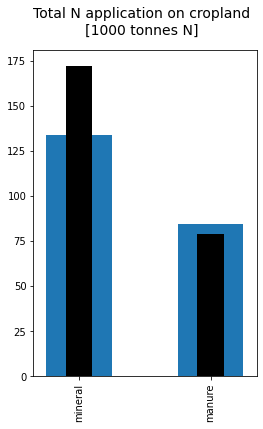

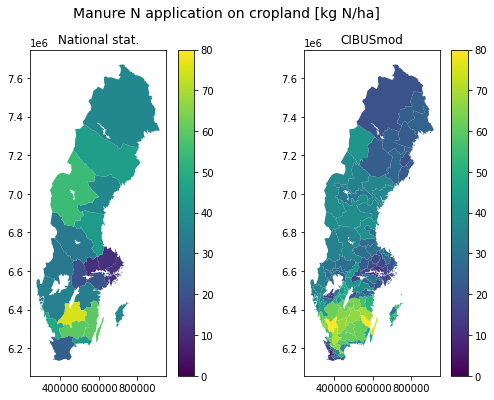

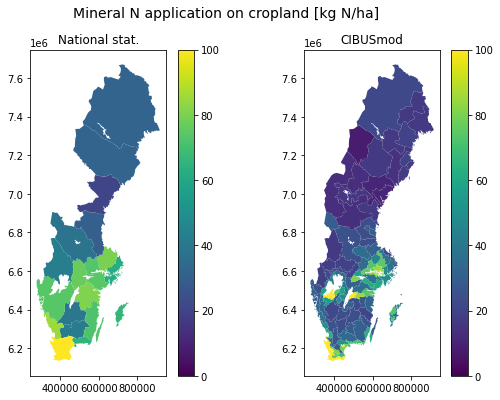

In [17]:
rel = cm.ParameterRetriever.get_rel('crop','land_use')
area = output.loc[(scn,year),'crp'].area.to_frame()
area['lu'] = [rel[c] for c in area.index.get_level_values('crop')]
area = (
    area.loc[area['lu'].isin(['cropland']),0]
    .groupby('region')
    .sum()
)

# Total manure and mineral fertiliser [tonnes]
plot_data = pd.Series(
    [
        output.loc[('none','2020'),'crp']
        .fertiliser.mineral_N
        .rename(rel).loc['cropland']
        .sum().sum(),
        output.loc[('none','2020'),'crp']
        .fertiliser.manure_N
        .rename(rel).loc['cropland']
        .sum().sum()
    ],
    index = ['mineral','manure']
)/1000000
fig, ax = plt.subplots(figsize=(4,6))
plot_data.plot.bar(ax = ax)
(stat_N_total/1000).plot.bar(width=0.2, color='black', ax = ax)
plt.suptitle('Total N application on cropland\n[1000 tonnes N]', size=14)
plt.show()


# Manure per ha
fig, axs = plt.subplots(1,2, figsize=(9,6))
ax = axs[0]
ax.set_title('National stat.')
plot.map_from_series(stat_N_per_ha['manure'], reg='län', ax=ax, vmin=0, vmax=80)

ax = axs[1]
ax.set_title('CIBUSmod')
plot_data = (
    output.loc[('none','2020'),'crp']
    .fertiliser.manure_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, ax=ax, vmin=0, vmax=80)
plt.suptitle('Manure N application on cropland [kg N/ha]', size=14)
plt.show()

# Mineral per ha
fig, axs = plt.subplots(1,2, figsize=(9,6))
ax = axs[0]
ax.set_title('National stat.')
plot.map_from_series(stat_N_per_ha['mineral'], reg='län', ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
plot_data = (
    output.loc[('none','2020'),'crp']
    .fertiliser.mineral_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, ax=ax, vmin=0, vmax=100)
plt.suptitle('Mineral N application on cropland [kg N/ha]', size=14)
plt.show()

### Check deviations from x0

In [ ]:
print('Crops max(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).max())
print('Crops min(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).min())
print('Animals max(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).max())
print('Animals min(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).min())

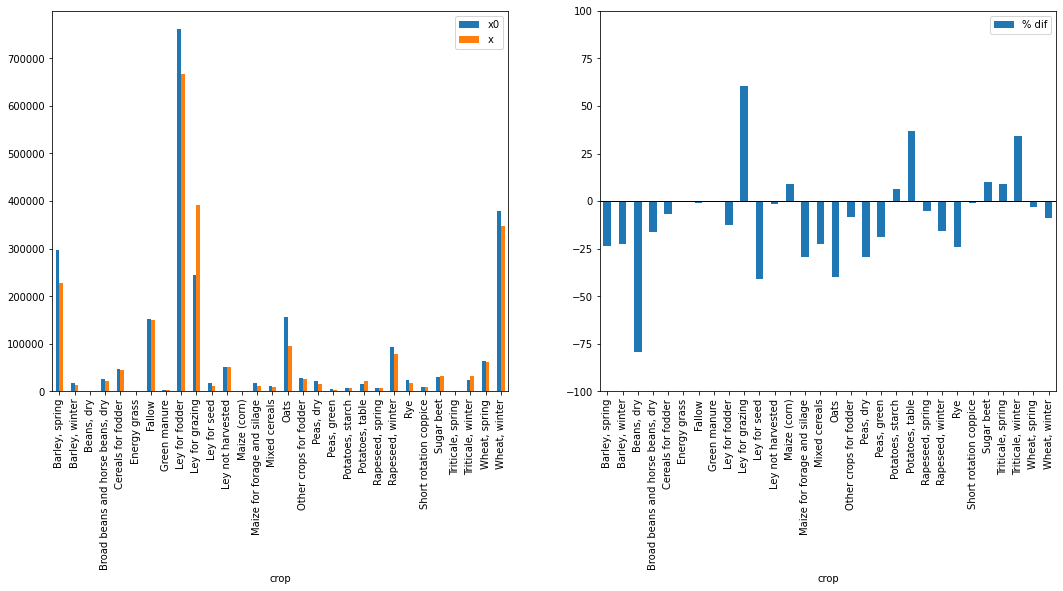

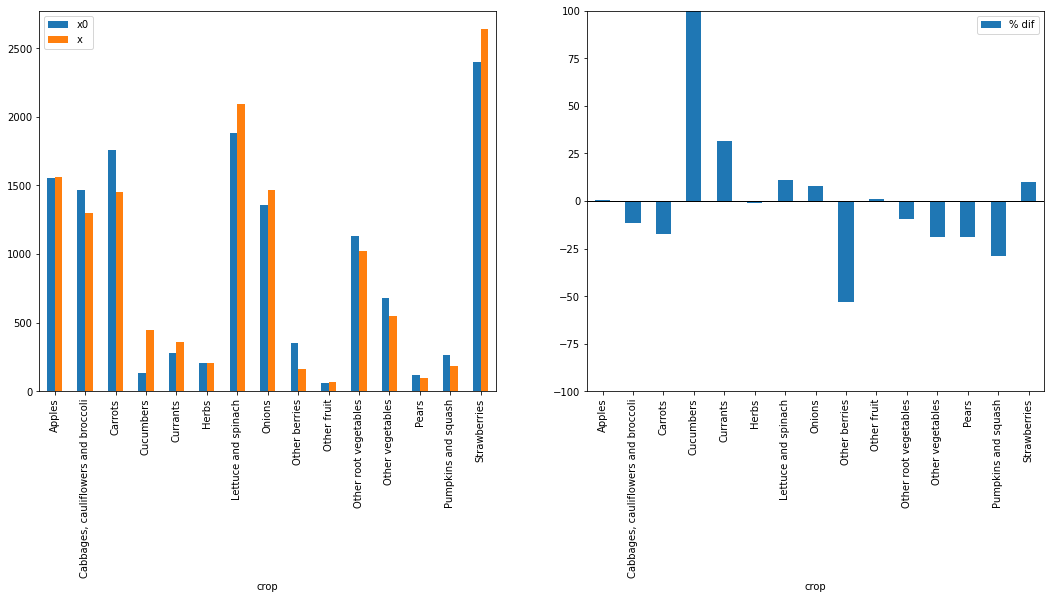

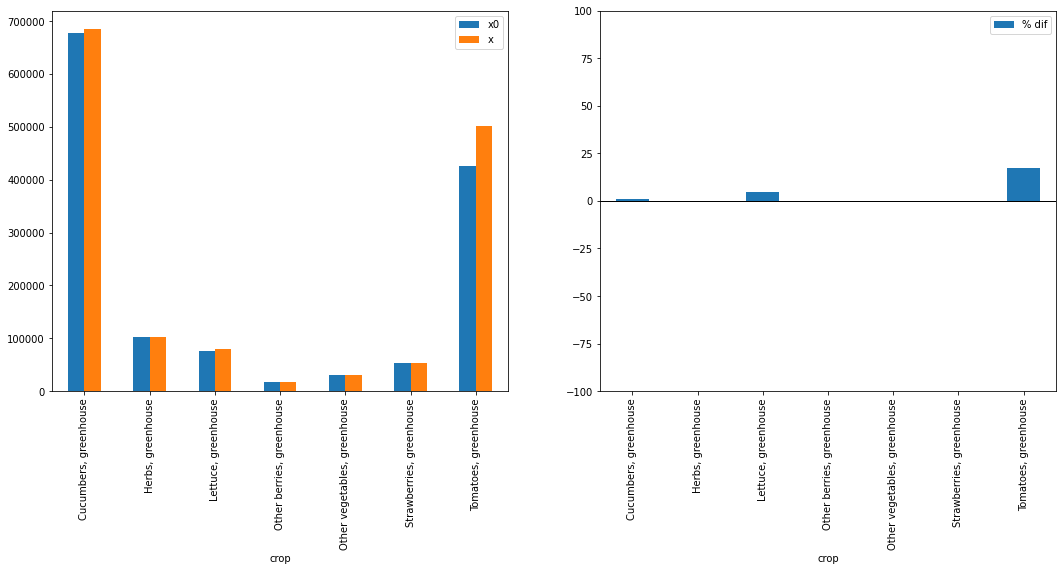

In [26]:
plot_data = (
    pd.concat([
        output.loc[('none','2020'),'crp'].area.groupby('crop').sum().rename('x'),
        geodist.x0['crp'].groupby('crop').sum().rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [
                x['x'],
                x['x0'],
                ((x['x']-x['x0'])/x['x0']*100)
            ],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

cg_dict = crops.par.get_rel('crop','crop_group')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables','Berries','Fruit trees']
gh = ['Vegetables, greenhouse','Berries, greenhouse']
sng = ['Semi-natural grasslands']

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(hr)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(hr)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(gh)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(gh)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

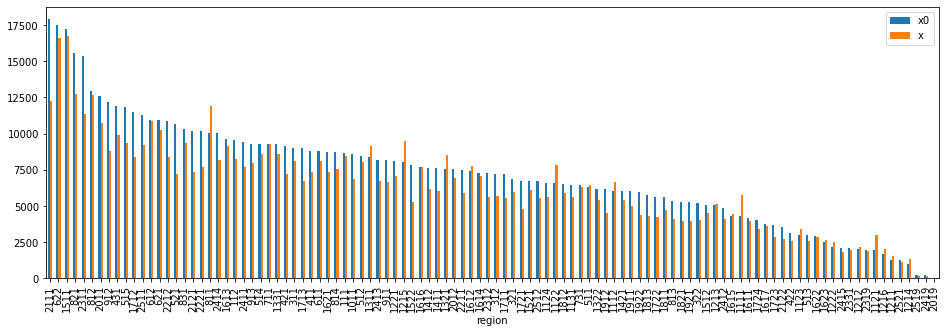

In [27]:
crp = 'Ley for fodder'

fig, ax = plt.subplots(figsize=(16,5))

pd.concat([
    geodist.x0['crp'].xs(crp, level='crop').groupby('region').sum().rename('x0'),
    output.loc[('none','2020'),'crp'].area.xs(crp, level='crop').groupby('region').sum().rename('x')
], axis=1).sort_values('x0', ascending=False).plot.bar(ax=ax)

plt.show()

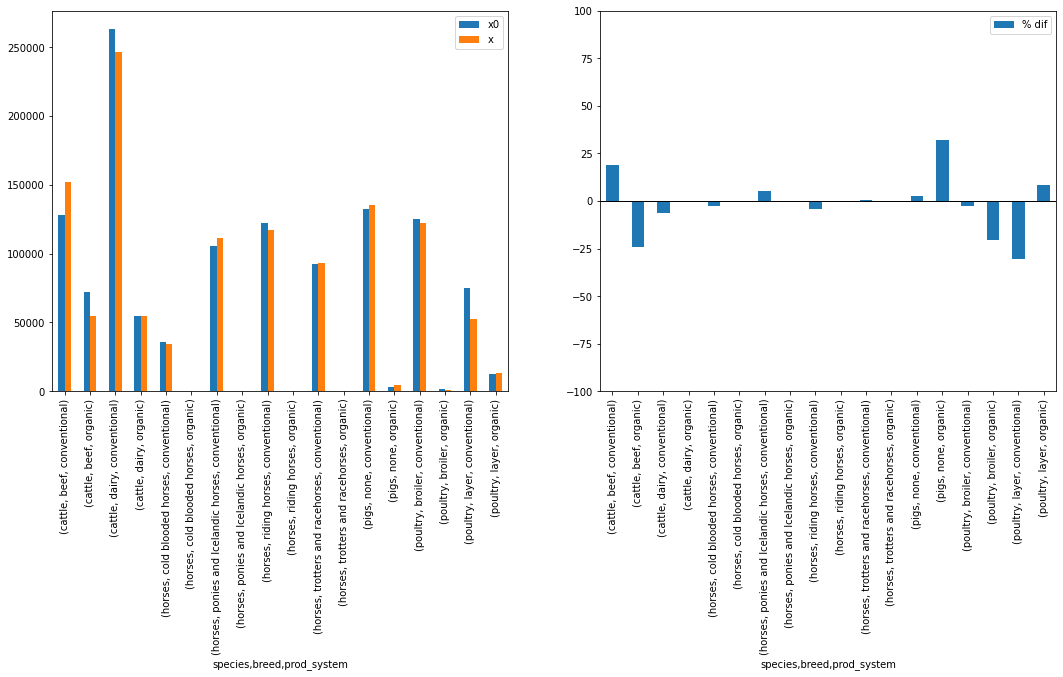

In [28]:
idx = pd.IndexSlice

plot_data = (
    pd.concat([
        output.loc[('none','2020'),'ani'].heads
        .loc[:,idx[:,:,:,:,[
            'cows','sows','gilts','broodmares','low-performing horses',
            'medium-performing horses','young horses','broilers','laying hens (16-28 weeks)',
            'laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters'
        ]]]
        .groupby(['species','breed','prod_system'], axis=1).sum()
        .sum()
        .rename('x')
        ,
        geodist.x0['ani']
        .groupby(['species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
)
# Adjust poultry to 100 heads
plot_data = \
plot_data.mul(np.where(plot_data.index.get_level_values('species')=='poultry',1/100,1), axis=0)
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

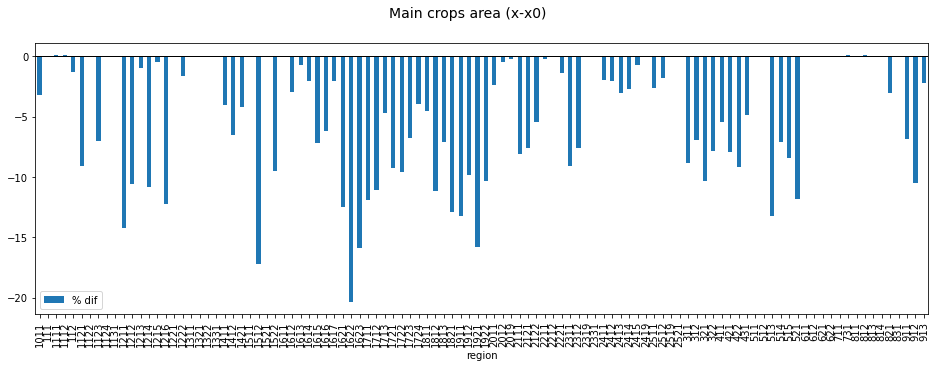

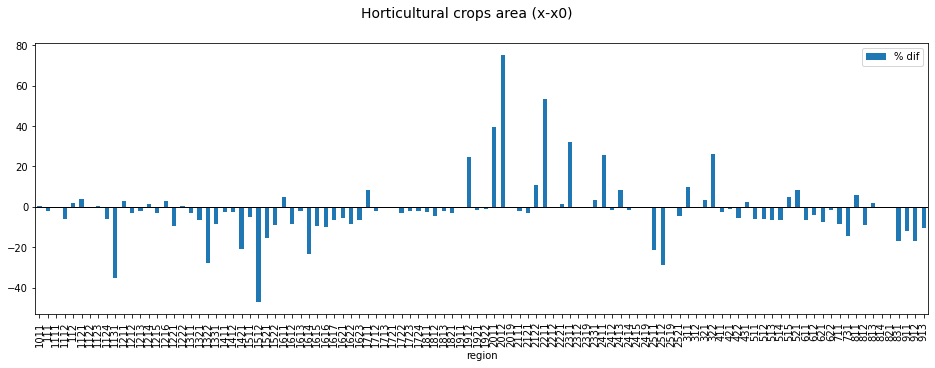

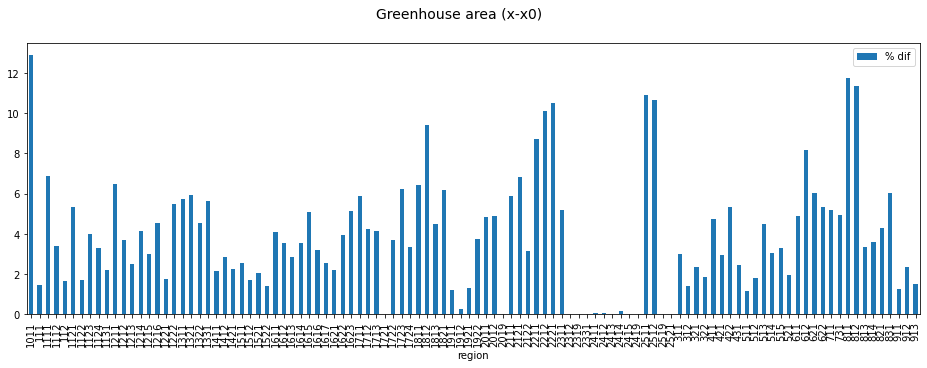

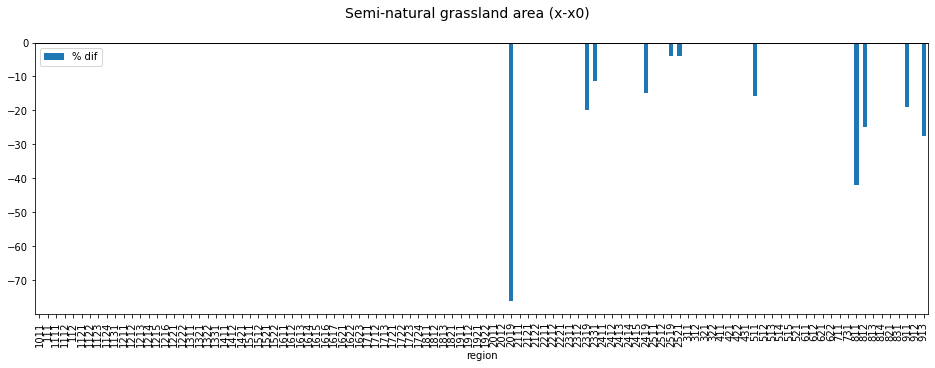

In [30]:

plot_data_ = (pd.concat([
    output.loc[('none','2020'),'crp'].area.groupby(['crop','region']).sum().rename('x'),
    geodist.x0['crp'].groupby(['crop','region']).sum().rename('x0')
], axis=1)
)

cg_dict = crops.par.get_rel('crop','crop_group')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables','Berries','Fruit trees']
gh = ['Vegetables, greenhouse','Berries, greenhouse']
sng = ['Semi-natural grasslands']

# Crops
plot_data = plot_data_.loc[~plot_data_['cg'].isin(hr+gh+sng)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.suptitle('Main crops area (x-x0)', size=14)
plt.show()

# Horti
plot_data = plot_data_.loc[plot_data_['cg'].isin(hr)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.suptitle('Horticultural crops area (x-x0)', size=14)
plt.show()

# Greenhouse
plot_data = plot_data_.loc[plot_data_['cg'].isin(gh)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.suptitle('Greenhouse area (x-x0)', size=14)
plt.show()

# Semi-natural grasslands
plot_data = plot_data_.loc[plot_data_['cg'].isin(sng)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.suptitle('Semi-natural grassland area (x-x0)', size=14)
plt.show()